In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import sys
sys.path.insert(0, '..')
import codes.toolbox as tb

import warnings
warnings.filterwarnings("ignore")

from importlib import reload
reload(tb)

<module 'codes.toolbox' from '/Users/cfan/Documents/projects/202604_dailyStrategy/notebooks/../codes/toolbox.py'>

In [3]:
dl = tb.DataLoader('../data')

In [76]:
dl

DataLoader(symbols=0G-USDT-SWAP .. ZRXUSDT (844 symbols), exchanges=(binance, bitget, bybit, okex), instruments=(futures, perps, spot, swap), dates=20251013 .. 20260412 (182 days))

In [9]:
def plotField(dl, ticker, market, instrument, fieldName='close'):
    
    prices = dl.get(ticker, market, instrument)[fieldName]
    
    #plt.figure()
    plt.plot(prices.values)
    plt.grid(True)

In [4]:
targets = ['MYX', 'COAI', 'RIVER', 'AIA', 'SIREN', 'RAVE', 'BEAT', 'UAI', 'BULLA', 'ARIA', 'STI', 'HUMNANITY', 'VVV']
bumpTickers = [s for s in dl.availSymbols('binance', 'futures') if any([s.find(t) !=-1 for t in targets]) ]

In [5]:
bumpTickers

['AIAUSDT',
 'ARIAUSDT',
 'BEATUSDT',
 'BLUAIUSDT',
 'BULLAUSDT',
 'COAIUSDT',
 'KAIAUSDT',
 'MYXUSDT',
 'RAVEUSDT',
 'RIVERUSDT',
 'SIRENUSDT',
 'UAIUSDT',
 'VVVUSDT']

In [80]:
targets = ['MYX', 'COAI', 'RIVER', 'AIA', 'SIREN', 'RAVE', 'BEAT', 'UAI', 'BULLA', 'ARIA', 'STI', 'HUMNANITY', 'VVV']
[s for s in dl.availSymbols('bybit', 'perps') if any([s.find(t) !=-1 for t in targets]) ]

['ARIAUSDT', 'COAIUSDT', 'KAIAUSDT', 'MYXUSDT', 'SIRENUSDT', 'VVVUSDT']

In [83]:
targets = ['MYX', 'COAI', 'RIVER', 'AIA', 'SIREN', 'RAVE', 'BEAT', 'UAI', 'BULLA', 'ARIA', 'STI', 'HUMNANITY', 'VVV']
[s for s in dl.availSymbols('bybit', 'spot') if any([s.find(t) !=-1 for t in targets]) ]

['KAIAUSDT', 'VVVUSDT']

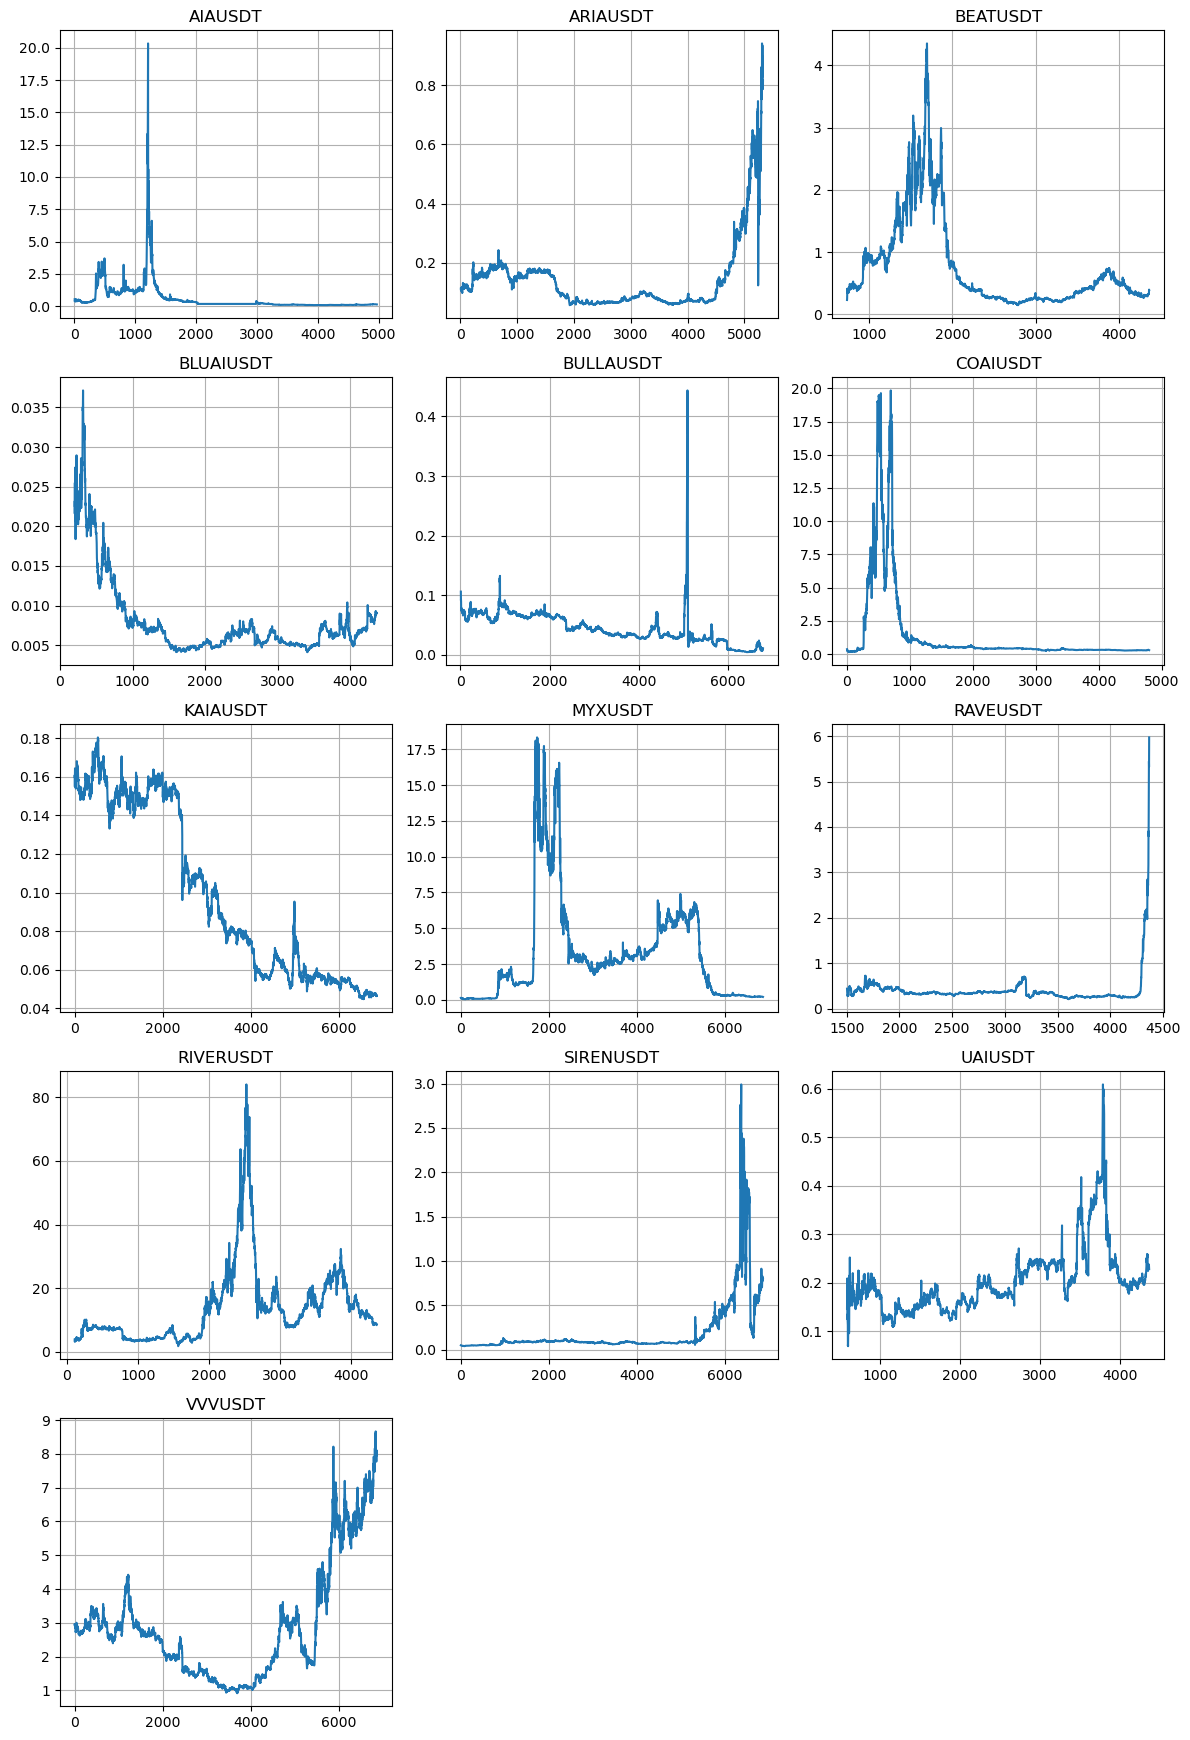

In [10]:
for _, ticker in tb.subplots(bumpTickers):
    plotField(dl, ticker, 'binance', 'futures')
    plt.title(ticker)

In [38]:
def scaleFeature(x):
    scale = np.quantile(abs(x), 0.1)
    scale_x = np.sign(x)*(1.0 - np.exp(-1.0*x/scale))
    return scale_x

In [61]:
def plotAllQuantities(dl, ticker, market, instrument):
    
    ncols = 1
    
    data = dl.get(ticker, market, instrument)
    data['sign(cvd_usdt)'] = np.sign(data['cvd_usdt'])
    data['log10(cvd_usdt)'] = np.log10(abs(data['cvd_usdt']))

    cols = list(dl.columns[1:]) + ['sign(cvd_usdt)', 'log10(cvd_usdt)']
    nrows = len(cols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 1.5 * nrows),
                             sharex=True, squeeze=False)

    
    for i in range(nrows):
        plt.sca(axes[i][0])
        col = cols[i]
        plt.plot(data[col].values, label = col)
        plt.legend()
        plt.grid(True)

    plt.tight_layout()

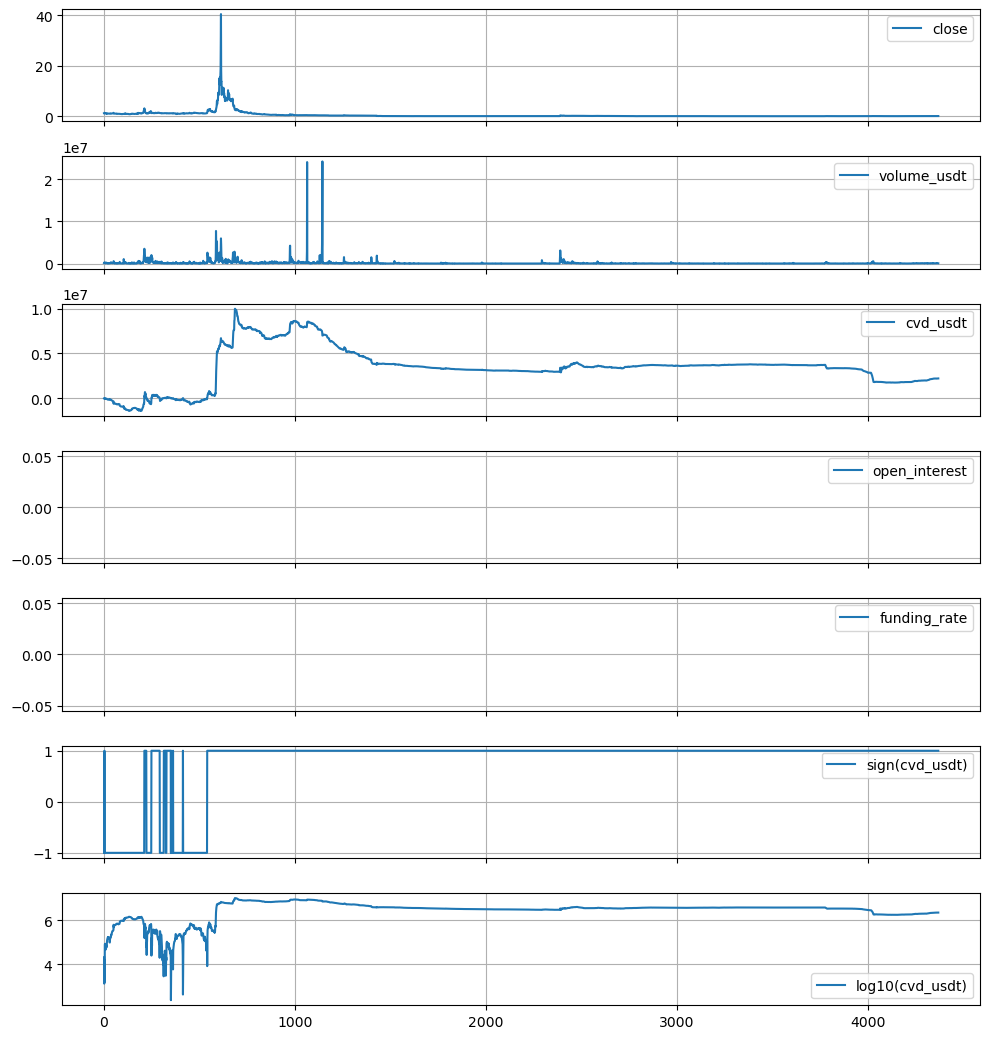

In [62]:
plotAllQuantities(dl, 'AIAUSDT', 'bitget', 'spot')

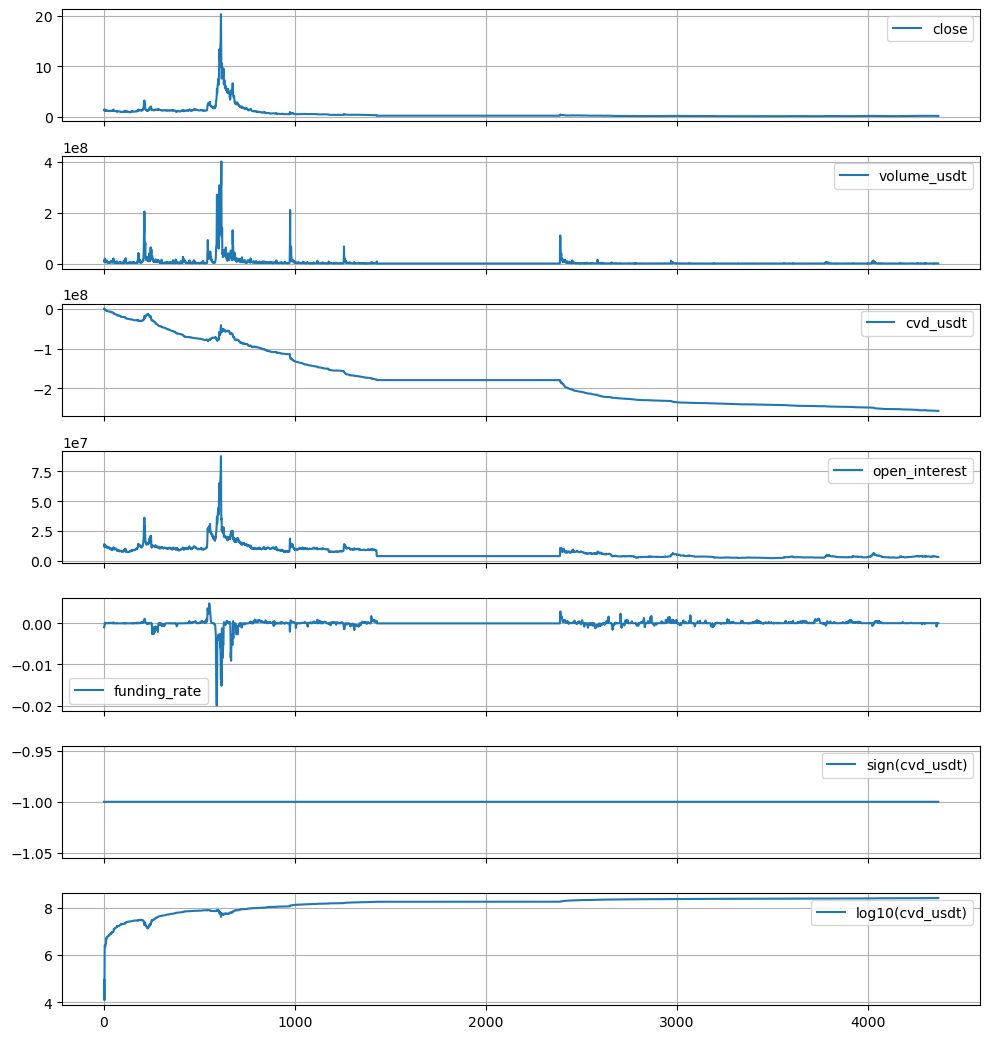

In [63]:
plotAllQuantities(dl, 'AIAUSDT', 'binance', 'futures')

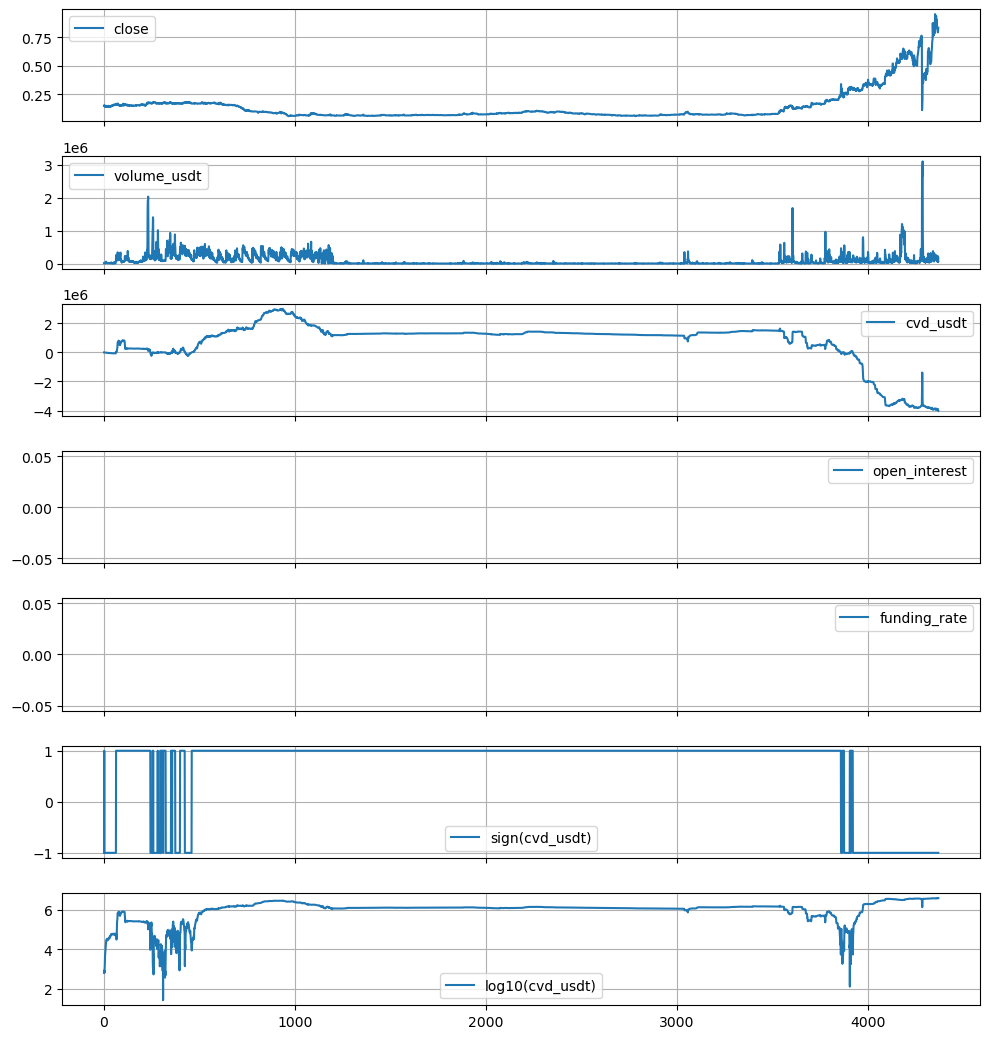

In [66]:
plotAllQuantities(dl, 'ARIAUSDT', 'bitget', 'spot')

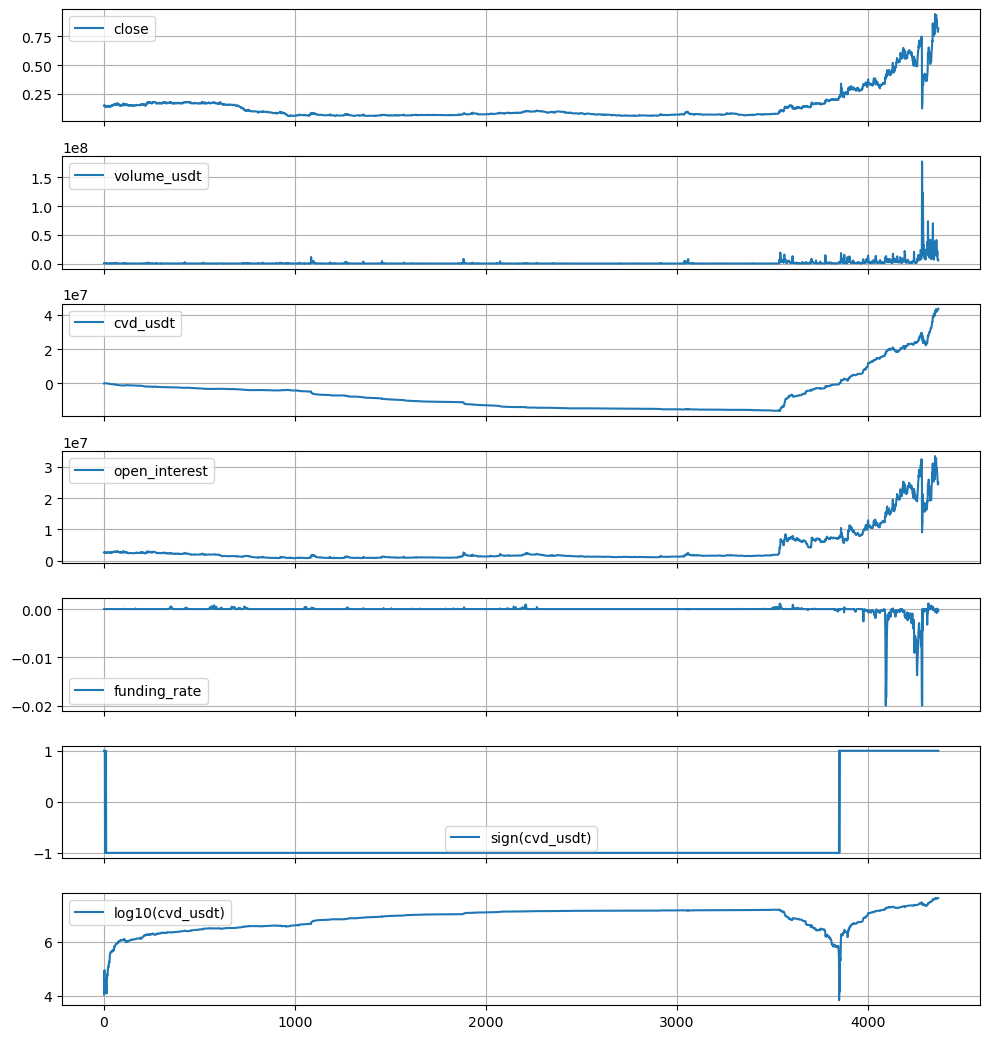

In [65]:
plotAllQuantities(dl, 'ARIAUSDT', 'binance', 'futures')

In [87]:
dl

DataLoader(symbols=0G-USDT-SWAP .. ZRXUSDT (844 symbols), exchanges=(binance, bitget, bybit, okex), instruments=(futures, perps, spot, swap), dates=20251013 .. 20260412 (182 days))

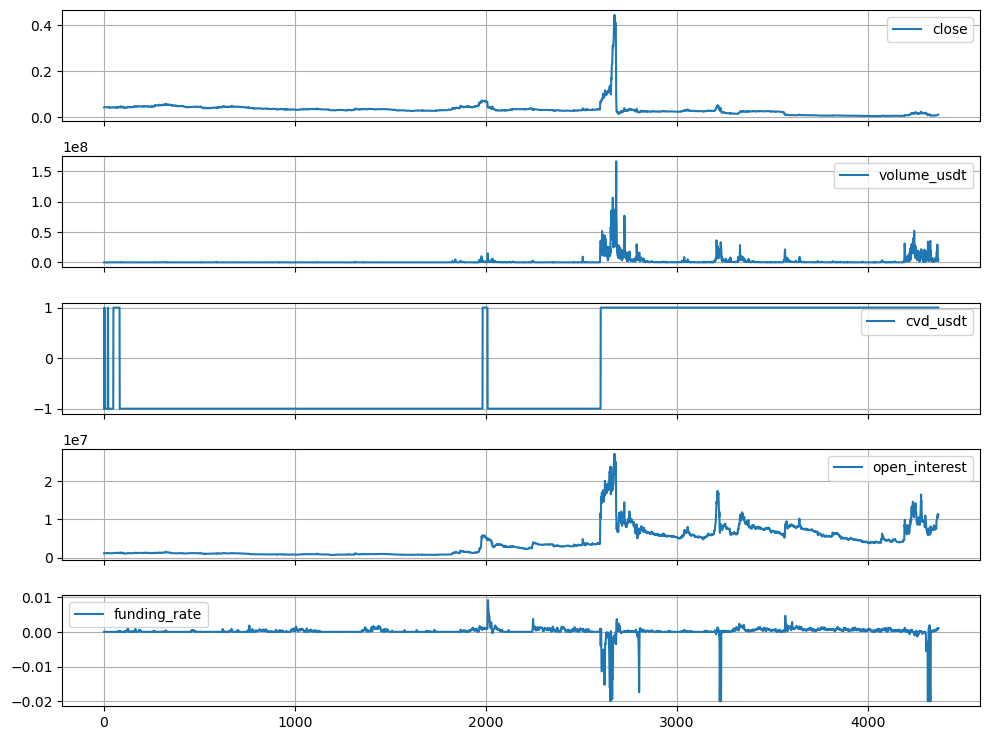

In [50]:
plotAllQuantities(dl, 'BULLAUSDT', 'binance', 'futures')

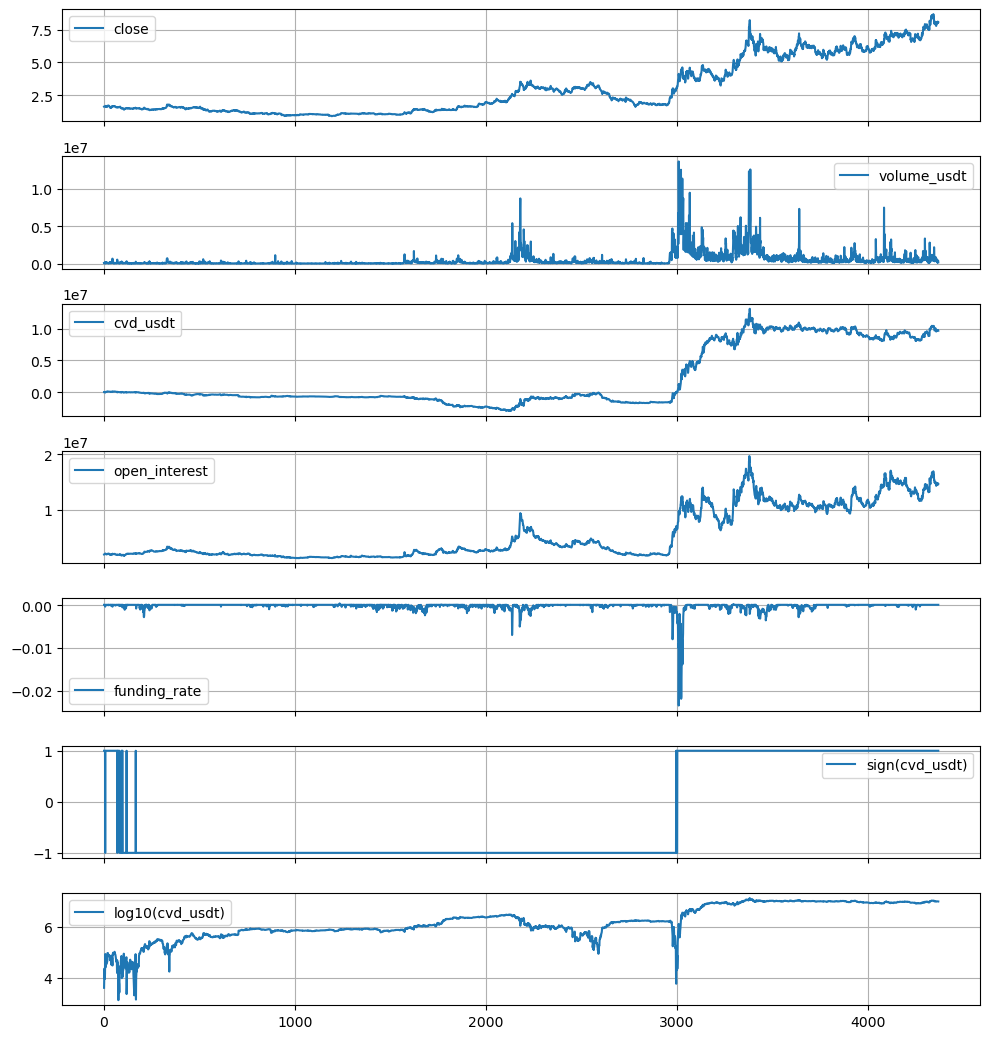

In [85]:
plotAllQuantities(dl, 'VVVUSDT', 'bybit', 'perps')

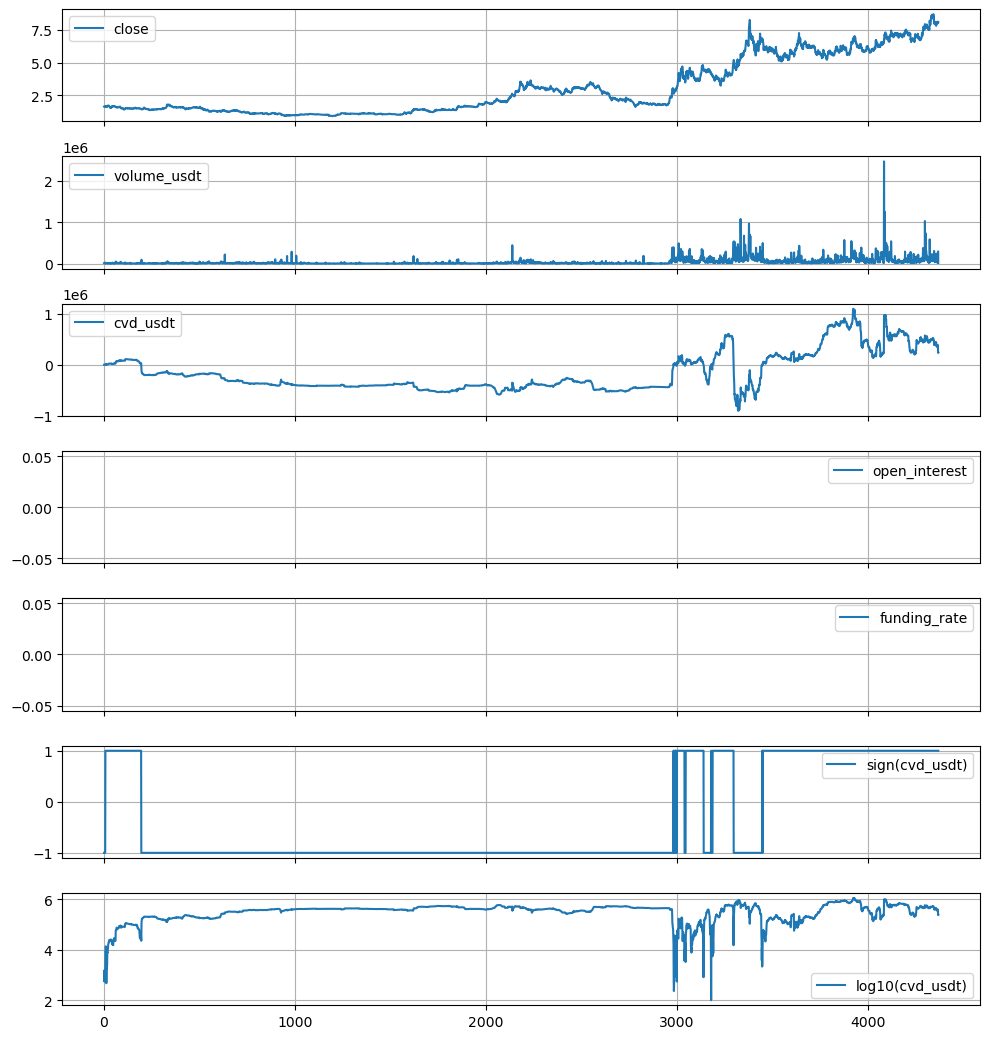

In [84]:
plotAllQuantities(dl, 'VVVUSDT', 'bybit', 'spot')

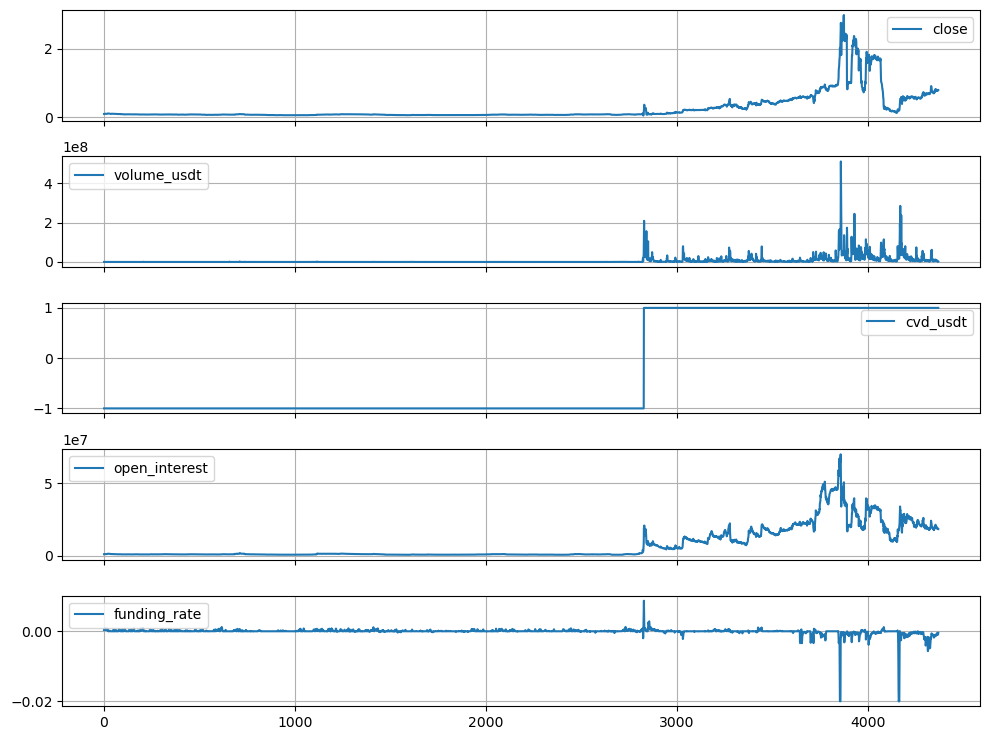

In [47]:
plotAllQuantities(dl, 'SIRENUSDT', 'binance', 'futures')

In [2]:
features = ['dprice_es4', 'dprice_ratio_es4', 'dprice_es8', 'dprice_ratio_es8',
       'dprice_es24', 'dprice_ratio_es24', 'oi_es4', 'doi_es4', 'doi_ratio_es4', 'oi_native_es4', 'doi_native_es4',
       'doi_native_ratio_es4', 'cvd_es4', 'cvd_es8', 'cvd_es24', 'dcvd_es4', 'dcvd_es8', 'dcvd_es24', 'dcvd_ratio_es4', 'dcvd_ratio_es8',
       'cvd_vol_es4', 'cvd_vol_es8', 'dcvd_vol_es4', 'dcvd_vol_es8',
       'dcvd_ratio_es24', 'abs_cvd_ema240', 'cvd_es4_norm', 'dcvd_es4_norm','cvd_es8_norm', 'dcvd_es8_norm', 'cvd_es24_norm', 'dcvd_es24_norm',
       'd_abs_cvd_es_bar_es4', 'd_abs_cvd_es_bar_ratio_es4', 'd_abs_cvd_es_bar_es4_norm', 'spot_cvd_es4', 'spot_cvd_es8',
       'spot_cvd_es24', 'dspot_cvd_es4', 'dspot_cvd_es8', 'dspot_cvd_es24','dspot_cvd_ratio_es4', 'dspot_cvd_ratio_es8', 
       'dspot_cvd_ratio_es24', 'spot_cvd_es4_norm', 'dspot_cvd_es4_norm', 'spot_cvd_es8_norm', 'dspot_cvd_es8_norm', 
       'spot_cvd_es24_norm', 'dspot_cvd_es24_norm', 'd_abs_spot_cvd_es_bar_es4', 'd_abs_spot_cvd_es_bar_ratio_es4', 
       'd_abs_spot_cvd_es_bar_es4_norm', 'funding_rate', 'funding_rate_avg', 'spot_fut_vol_ratio', 'spot_fut_vol_es24_ratio']

features2 = ['dprice_es4', 'dprice_ratio_es4', 'dprice_es8', 'dprice_ratio_es8',
       'dprice_es24', 'dprice_ratio_es24', 'oi_es4', 'doi_es4',
       'doi_ratio_es4', 'oi_native_es4', 'doi_native_es4',
       'doi_native_ratio_es4', 'cvd_es4', 'cvd_es8', 'cvd_es24', 'dcvd_es4',
       'dcvd_es8', 'dcvd_es24', 'cvd_vol_es4', 'dcvd_vol_es4', 'cvd_vol_es8',
       'dcvd_vol_es8', 'dcvd_ratio_es4', 'dcvd_ratio_es8', 'dcvd_ratio_es24',
       'abs_cvd_ema240', 'cvd_es4_norm', 'dcvd_es4_norm', 'cvd_es8_norm',
       'dcvd_es8_norm', 'cvd_es24_norm', 'dcvd_es24_norm',
       'd_abs_cvd_es_bar_es4', 'd_abs_cvd_es_bar_ratio_es4',
       'd_abs_cvd_es_bar_es4_norm', 'spot_cvd_es4', 'spot_cvd_es8',
       'spot_cvd_es24', 'dspot_cvd_es4', 'dspot_cvd_es8', 'dspot_cvd_es24',
       'dspot_cvd_ratio_es4', 'dspot_cvd_ratio_es8', 'dspot_cvd_ratio_es24',
       'spot_cvd_es4_norm', 'dspot_cvd_es4_norm',
       'spot_cvd_es8_norm', 'dspot_cvd_es8_norm', 'spot_cvd_es24_norm',
       'dspot_cvd_es24_norm', 'd_abs_spot_cvd_es_bar_es4',
       'd_abs_spot_cvd_es_bar_ratio_es4', 'd_abs_spot_cvd_es_bar_es4_norm',  'spot_fut_vol_ratio',  
       'spot_fut_vol_es24_ratio', 'log_oi_level', 'funding_7d_avg', 'ret_1h_pct', 'ret_4h_pct', 'ret_1d_pct',
       'ret_3d_pct', 'vol_1h_pct', 'vol_24h_pct', 'vol_chg_4h_pct', 'oi_chg_4h_pct', 'oi_3d_chg_pct', 'oi_7d_chg_pct', 
       'oi_coin_1h_chg_pct', 'oi_coin_chg_4h_pct', 'oi_coin_24h_chg_pct', 'oi_coin_3d_chg_pct',
       'oi_coin_7d_chg_pct', 'perp_cvd_1h', 'perp_cvd_4h', 'perp_cvd_24h',
       'perp_cvd_7d', 'spot_cvd_1h', 'spot_cvd_4h', 'spot_cvd_24h',
       'spot_cvd_7d', 'multi_exchange_spot_cvd_7d', 'total_cvd_7d',
       'multi_exchange_oi_7d_chg', 'spot_price_vs_perp', 'funding_rate',
       'funding_rate_avg', ]

In [4]:
set(features2) - set(features)

{'funding_7d_avg',
 'log_oi_level',
 'multi_exchange_oi_7d_chg',
 'multi_exchange_spot_cvd_7d',
 'oi_3d_chg_pct',
 'oi_7d_chg_pct',
 'oi_chg_4h_pct',
 'oi_coin_1h_chg_pct',
 'oi_coin_24h_chg_pct',
 'oi_coin_3d_chg_pct',
 'oi_coin_7d_chg_pct',
 'oi_coin_chg_4h_pct',
 'perp_cvd_1h',
 'perp_cvd_24h',
 'perp_cvd_4h',
 'perp_cvd_7d',
 'ret_1d_pct',
 'ret_1h_pct',
 'ret_3d_pct',
 'ret_4h_pct',
 'spot_cvd_1h',
 'spot_cvd_24h',
 'spot_cvd_4h',
 'spot_cvd_7d',
 'spot_price_vs_perp',
 'total_cvd_7d',
 'vol_1h_pct',
 'vol_24h_pct',
 'vol_chg_4h_pct'}